## The following study is based on the "in-vehicle-coupon-recommendation.csv" dataset which consists of data collected through a poll by Amazon Mechanical Turk. The said dataset was retrieved from UCI Machine Learning Repository a website consisting of a variety of machine learning datasets. 
## The purpose of using this dataset is to try and improve the accuracy related to in-vehicle coupon recommendations using 2 different machine learning models and analyze which one performs the best for this particular dataset.
## This is a classification problem as the target variable has 'yes/no' values and the purpose is to accurately classify whether the coupon will be accepted or not. 

In [439]:
# logistic_regression_banking_data.ipynb by Prof. Jaswinder singh was used as a reference for some model building and cross-validation functions

## Importing the required librabries and setting the environment

In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import plotly.express as px
pd.set_option('display.max_columns', None)
pd.reset_option('future.no_silent_downcasting', True)
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

## Importing the data and performing initial inspection

In [282]:
data=pd.read_csv("in-vehicle-coupon-recommendation.csv") # Importing the data file

In [283]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,1,0,0,1,0


In [284]:
data.info()     # Understanding the different variable types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [285]:
data.describe().T      # basic summary

,count,mean,std,min,25%,50%,75%,max
temperature,12684.0,63.301798,19.154486,30.0,55.0,80.0,80.0,80.0
has_children,12684.0,0.414144,0.492593,0.0,0.0,0.0,1.0,1.0
toCoupon_GEQ5min,12684.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
toCoupon_GEQ15min,12684.0,0.561495,0.496224,0.0,0.0,1.0,1.0,1.0
toCoupon_GEQ25min,12684.0,0.119126,0.323950,0.0,0.0,0.0,0.0,1.0
direction_same,12684.0,0.214759,0.410671,0.0,0.0,0.0,0.0,1.0
direction_opp,12684.0,0.785241,0.410671,0.0,1.0,1.0,1.0,1.0
Y,12684.0,0.568433,0.495314,0.0,0.0,1.0,1.0,1.0


In [286]:
columns = ['temperature','has_children','toCoupon_GEQ5min','toCoupon_GEQ15min','toCoupon_GEQ25min','direction_same','direction_opp','Y']

In [287]:
for col in columns:
    print(data[col].value_counts())

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64
has_children
0    7431
1    5253
Name: count, dtype: int64
toCoupon_GEQ5min
1    12684
Name: count, dtype: int64
toCoupon_GEQ15min
1    7122
0    5562
Name: count, dtype: int64
toCoupon_GEQ25min
0    11173
1     1511
Name: count, dtype: int64
direction_same
0    9960
1    2724
Name: count, dtype: int64
direction_opp
1    9960
0    2724
Name: count, dtype: int64
Y
1    7210
0    5474
Name: count, dtype: int64


In [288]:
data.drop('direction_opp',axis=1,inplace=True)     # dropping the unnecessary column and permanently removing it using inplace=True

In [289]:
data.drop('toCoupon_GEQ5min',axis=1,inplace=True)

In [290]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,car,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,0,0,0,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,0,0,0,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,NaN,never,never,NaN,4~8,1~3,1,0,0,0


In [291]:
data.isnull().sum(),data.shape         # finding out the number of missing values present in each column

(destination                 0
 passanger                   0
 weather                     0
 temperature                 0
 time                        0
 coupon                      0
 expiration                  0
 gender                      0
 age                         0
 maritalStatus               0
 has_children                0
 education                   0
 occupation                  0
 income                      0
 car                     12576
 Bar                       107
 CoffeeHouse               217
 CarryAway                 151
 RestaurantLessThan20      130
 Restaurant20To50          189
 toCoupon_GEQ15min           0
 toCoupon_GEQ25min           0
 direction_same              0
 Y                           0
 dtype: int64,
 (12684, 24))

In [292]:
# Calculating percentage of missing values present in each column
((data.isna().sum()/len(data)) * 100).sort_values(ascending=False)

car                     99.148534
CoffeeHouse              1.710817
Restaurant20To50         1.490066
CarryAway                1.190476
RestaurantLessThan20     1.024913
Bar                      0.843582
destination              0.000000
passanger                0.000000
direction_same           0.000000
toCoupon_GEQ25min        0.000000
toCoupon_GEQ15min        0.000000
income                   0.000000
occupation               0.000000
education                0.000000
has_children             0.000000
maritalStatus            0.000000
age                      0.000000
gender                   0.000000
expiration               0.000000
coupon                   0.000000
time                     0.000000
temperature              0.000000
weather                  0.000000
Y                        0.000000
dtype: float64

In [293]:
# The car column has a lot of missing values (>99%). We can drop this column from further analysis.
data.drop(columns='car',axis=1,inplace=True)

In [294]:
# For the rest of the columns, the percent of missing values is very less (<2%). And since these are categorical features we will replace the 
# missing values with the mode of that column
df = data.apply(lambda x: x.fillna(x.mode().iloc[0]) if x.isnull().any() else x)

In [295]:
df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
Y                       0
dtype: int64

In [296]:
# Checking for duplicate rows and removing them.

In [297]:
duplicate_rows = df[df.duplicated()]
duplicate_rows.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,Y
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,0,Associates degree,Unemployed,Less than $12500,less1,never,1~3,less1,less1,1,1,0,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,0,Graduate degree (Masters or Doctorate),Management,$25000 - $37499,4~8,gt8,gt8,4~8,less1,1,1,0,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,0,Bachelors degree,Education&Training&Library,$50000 - $62499,1~3,never,4~8,1~3,less1,1,1,0,1
4324,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,46,Single,0,Some college - no degree,Protective Service,$25000 - $37499,1~3,never,4~8,1~3,1~3,1,1,0,1
4409,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,21,Single,0,Bachelors degree,Life Physical Social Science,$37500 - $49999,less1,never,less1,1~3,never,1,1,0,0


In [298]:
print(f"Shape of dataset before removing the duplicates: ",df.shape)
df = df.drop_duplicates(keep='last')                                     # Keeping the last occurence
print(f"Shape of the dataset after removing the duplicates: ",df.shape)

Shape of dataset before removing the duplicates:  (12684, 23)
Shape of the dataset after removing the duplicates:  (12610, 23)


In [299]:
# Finding number of unique values present in every categorical column
{col: df[col].nunique() for col in df.select_dtypes(include=['category', 'object']).columns}

{'destination': 3,
 'passanger': 4,
 'weather': 3,
 'time': 5,
 'coupon': 5,
 'expiration': 2,
 'gender': 2,
 'age': 8,
 'maritalStatus': 5,
 'education': 6,
 'occupation': 25,
 'income': 9,
 'Bar': 5,
 'CoffeeHouse': 5,
 'CarryAway': 5,
 'RestaurantLessThan20': 5,
 'Restaurant20To50': 5}

In [300]:
# Feature 'occupation' has 25 different categories in it.

In [301]:
print(df['occupation'].value_counts(normalize=True))          # setting normalize = True returns the percentages or proportions

occupation
Unemployed                                   0.147581
Student                                      0.124901
Computer & Mathematical                      0.110230
Sales & Related                              0.086281
Education&Training&Library                   0.074465
Management                                   0.065107
Office & Administrative Support              0.050595
Arts Design Entertainment Sports & Media     0.049722
Business & Financial                         0.043061
Retired                                      0.039096
Food Preparation & Serving Related           0.023632
Healthcare Practitioners & Technical         0.019350
Healthcare Support                           0.019191
Community & Social Services                  0.018953
Legal                                        0.017367
Transportation & Material Moving             0.017288
Architecture & Engineering                   0.013878
Personal Care & Service                      0.013878
Protective Servic

In [302]:
# We will group the categories that have frequency less than 1% into 'Other'

In [303]:
freq = df['occupation'].value_counts(normalize=True)
rare_occu = freq[freq<0.01].index                                                     # storing categories in a separate variable
df['occupation'] = df['occupation'].apply(lambda x: 'Other' if x in rare_occu else x) # if the category is present in 'rare_occu' then it will be grouped as other
df['occupation'].value_counts()

occupation
Unemployed                                  1861
Student                                     1575
Computer & Mathematical                     1390
Sales & Related                             1088
Education&Training&Library                   939
Management                                   821
Office & Administrative Support              638
Arts Design Entertainment Sports & Media     627
Business & Financial                         543
Retired                                      493
Food Preparation & Serving Related           298
Healthcare Practitioners & Technical         244
Healthcare Support                           242
Community & Social Services                  239
Legal                                        219
Transportation & Material Moving             218
Other                                        195
Architecture & Engineering                   175
Personal Care & Service                      175
Protective Service                           174
Life Phys

## Exploratory data analysis (EDA)

#### Univariate Analysis

In [306]:
list = df.columns.to_list()

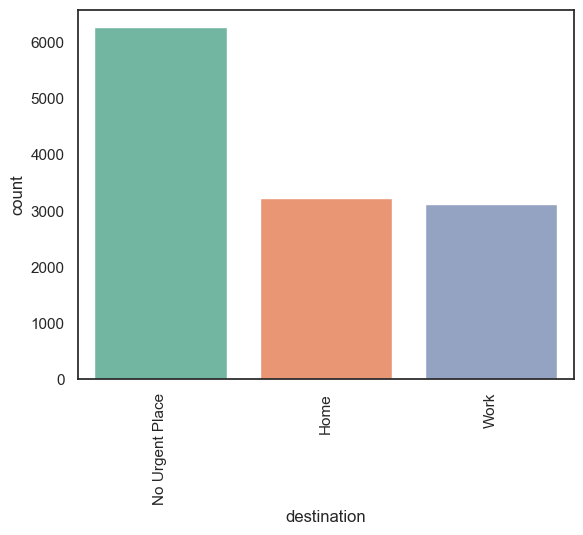

destination
No Urgent Place    49.690722
Home               25.614592
Work               24.694687
Name: count, dtype: float64


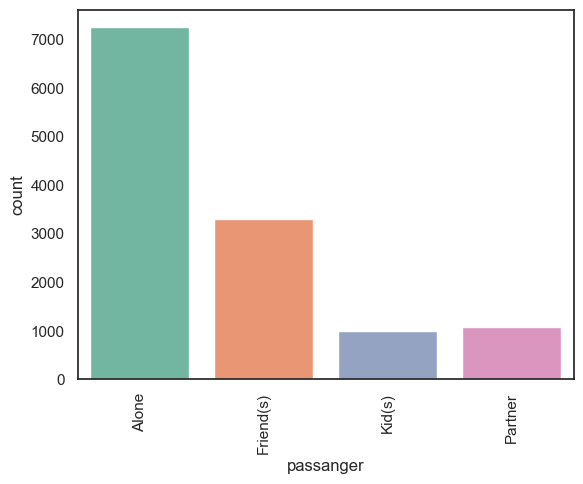

passanger
Alone        57.478192
Friend(s)    26.106265
Partner       8.477399
Kid(s)        7.938144
Name: count, dtype: float64


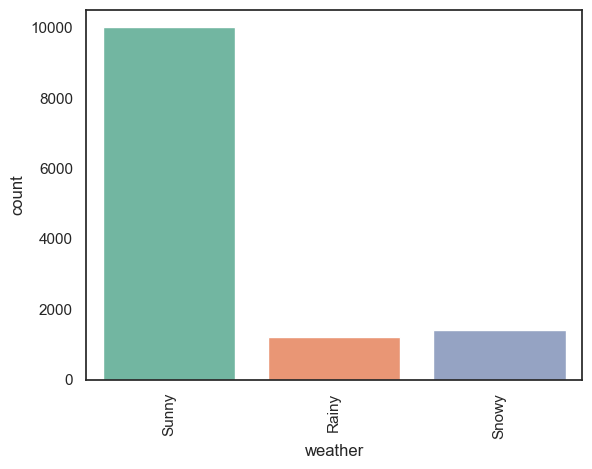

weather
Sunny    79.389374
Snowy    11.078509
Rainy     9.532117
Name: count, dtype: float64


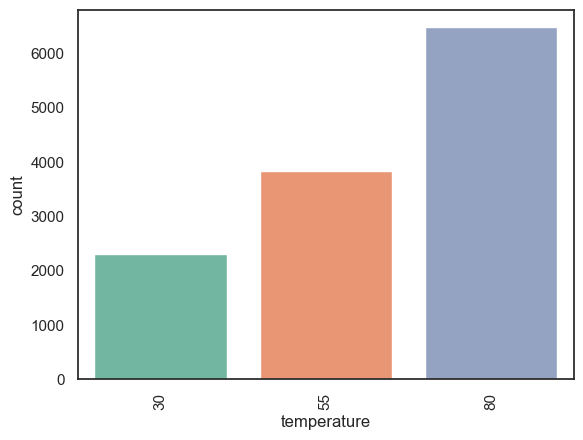

temperature
80    51.348136
55    30.372720
30    18.279144
Name: count, dtype: float64


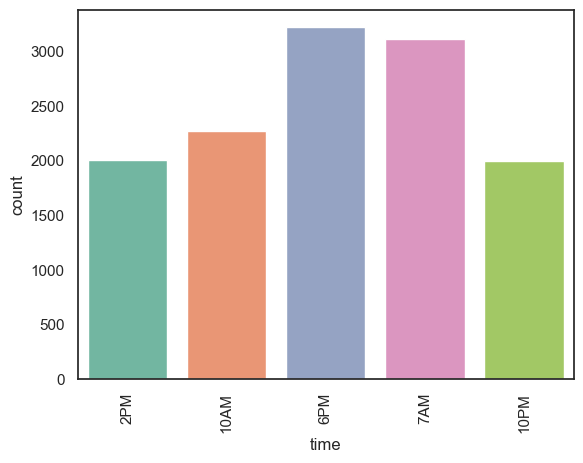

time
6PM     25.535289
7AM     24.694687
10AM    18.009516
2PM     15.908010
10PM    15.852498
Name: count, dtype: float64


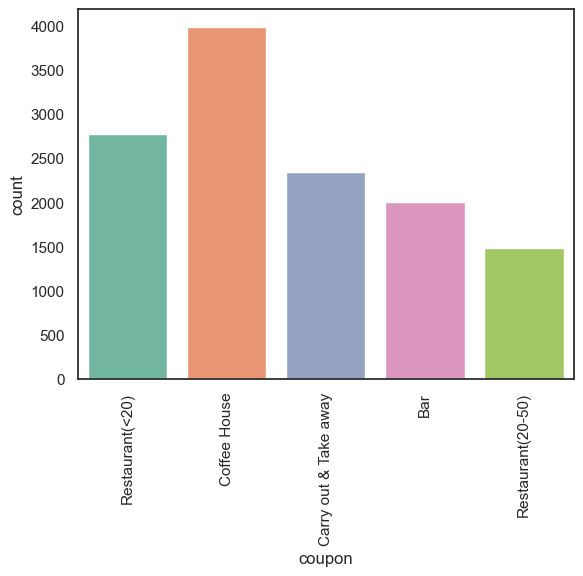

coupon
Coffee House             31.633624
Restaurant(<20)          22.038065
Carry out & Take away    18.588422
Bar                      15.939730
Restaurant(20-50)        11.800159
Name: count, dtype: float64


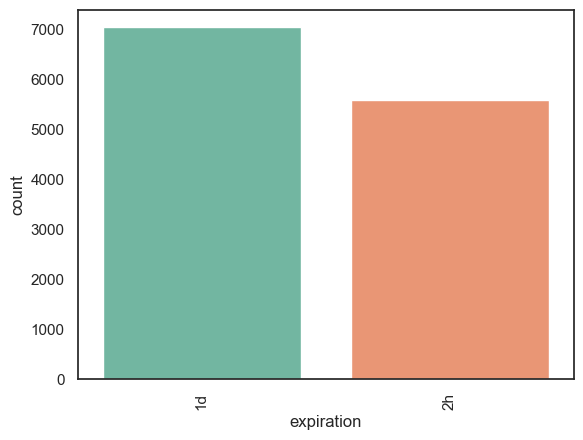

expiration
1d    55.757335
2h    44.242665
Name: count, dtype: float64


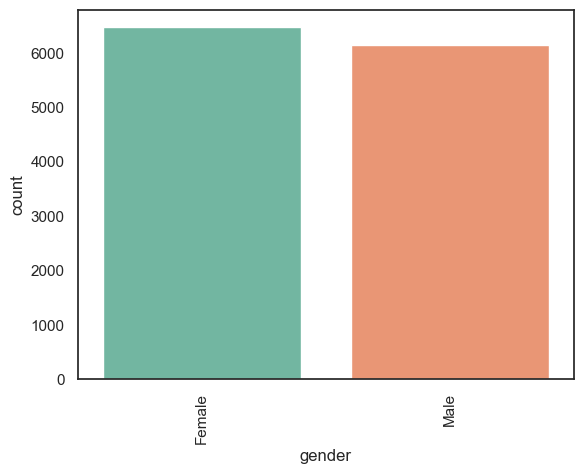

gender
Female    51.300555
Male      48.699445
Name: count, dtype: float64


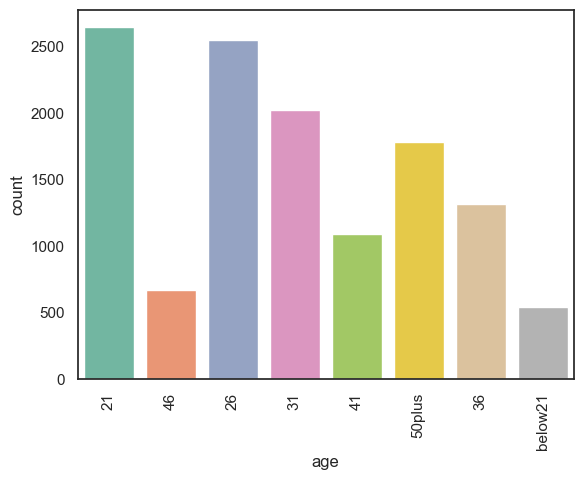

age
21         20.951626
26         20.206186
31         16.011102
50plus     14.123711
36         10.444092
41          8.636003
46          5.313243
below21     4.314036
Name: count, dtype: float64


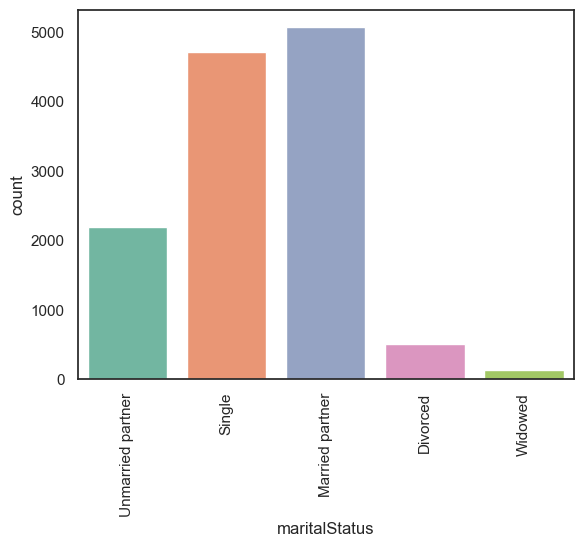

maritalStatus
Married partner      40.190325
Single               37.398890
Unmarried partner    17.327518
Divorced              4.052339
Widowed               1.030928
Name: count, dtype: float64


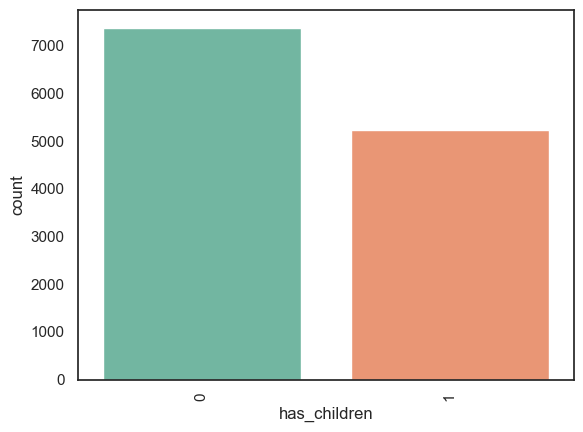

has_children
0    58.548771
1    41.451229
Name: count, dtype: float64


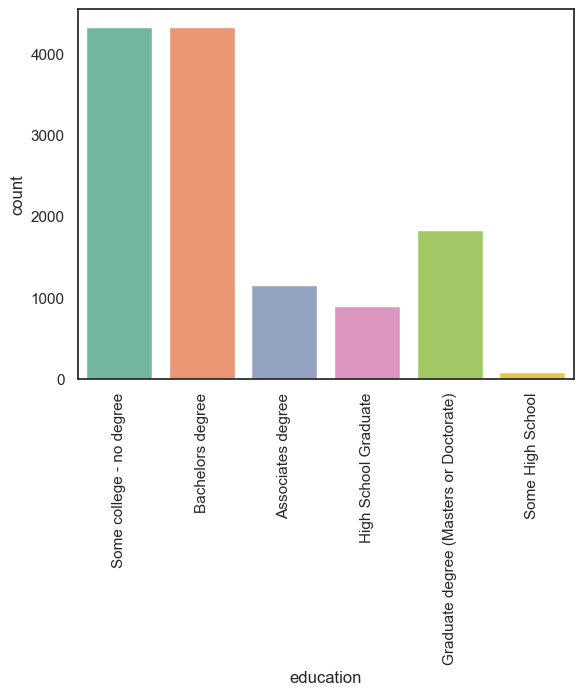

education
Some college - no degree                  34.298176
Bachelors degree                          34.282316
Graduate degree (Masters or Doctorate)    14.488501
Associates degree                          9.103886
High School Graduate                       7.129262
Some High School                           0.697859
Name: count, dtype: float64


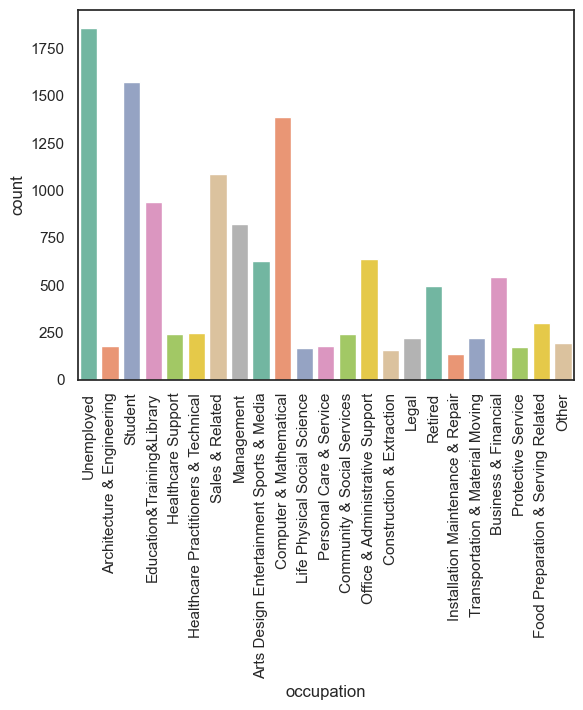

occupation
Unemployed                                  14.758128
Student                                     12.490087
Computer & Mathematical                     11.022998
Sales & Related                              8.628073
Education&Training&Library                   7.446471
Management                                   6.510706
Office & Administrative Support              5.059477
Arts Design Entertainment Sports & Media     4.972244
Business & Financial                         4.306106
Retired                                      3.909596
Food Preparation & Serving Related           2.363204
Healthcare Practitioners & Technical         1.934972
Healthcare Support                           1.919112
Community & Social Services                  1.895321
Legal                                        1.736717
Transportation & Material Moving             1.728787
Other                                        1.546392
Architecture & Engineering                   1.387787
Personal Care & S

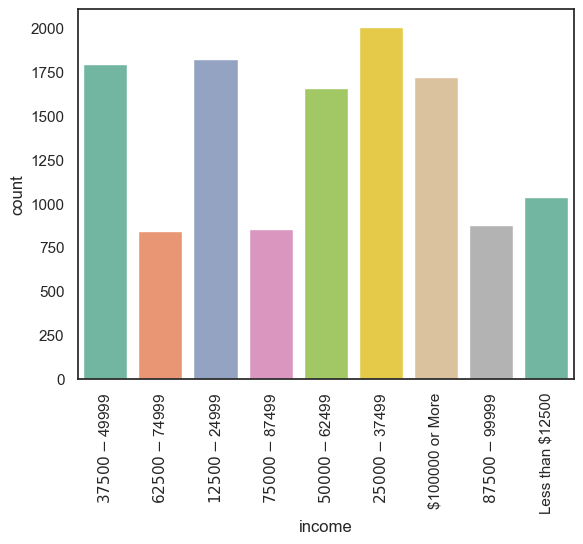

income
$25000 - $37499     15.908010
$12500 - $24999     14.472641
$37500 - $49999     14.234734
$100000 or More     13.616178
$50000 - $62499     13.124504
Less than $12500     8.199841
$87500 - $99999      6.970658
$75000 - $87499      6.788263
$62500 - $74999      6.685170
Name: count, dtype: float64


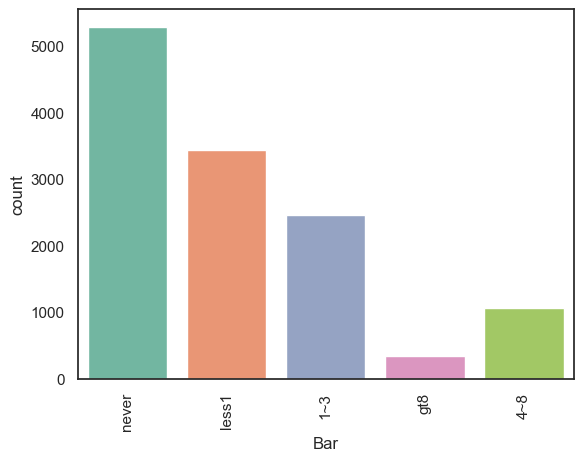

Bar
never    41.911182
less1    27.264076
1~3      19.571768
4~8       8.493259
gt8       2.759715
Name: count, dtype: float64


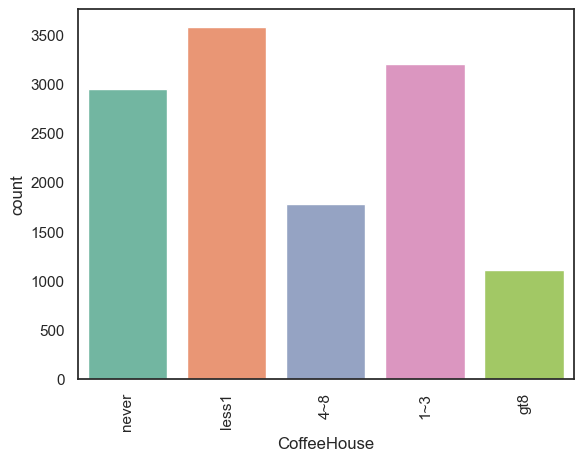

CoffeeHouse
less1    28.382236
1~3      25.368755
never    23.362411
4~8      14.107851
gt8       8.778747
Name: count, dtype: float64


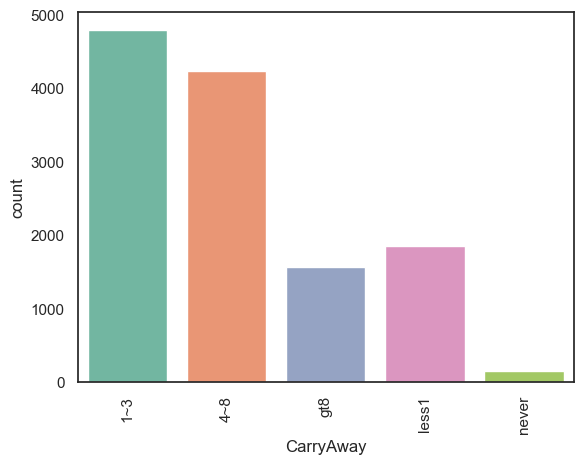

CarryAway
1~3      38.025377
4~8      33.639968
less1    14.662966
gt8      12.466297
never     1.205393
Name: count, dtype: float64


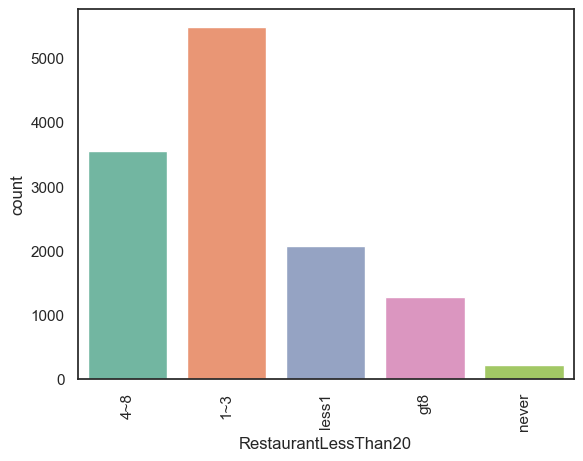

RestaurantLessThan20
1~3      43.497224
4~8      28.176051
less1    16.423473
gt8      10.166534
never     1.736717
Name: count, dtype: float64


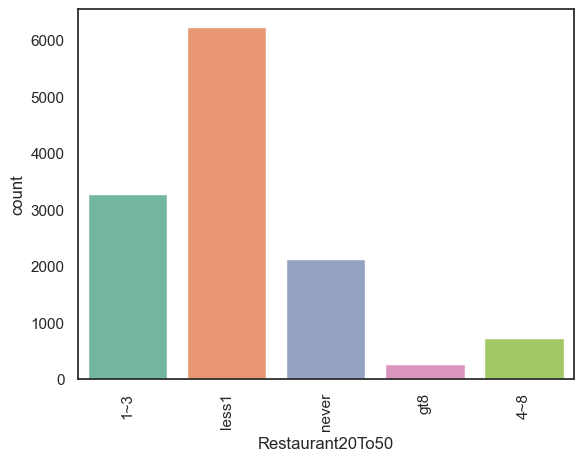

Restaurant20To50
less1    49.405234
1~3      25.900079
never    16.827914
4~8       5.773196
gt8       2.093577
Name: count, dtype: float64


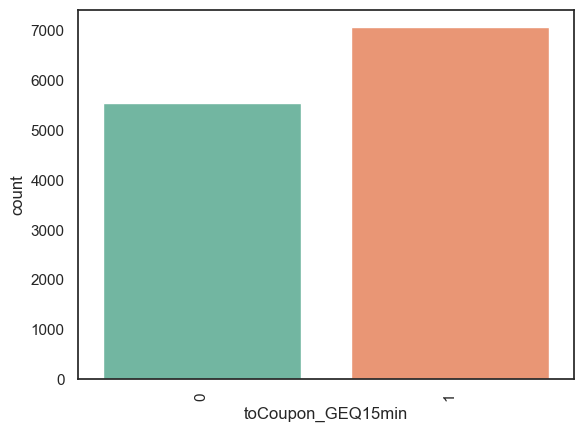

toCoupon_GEQ15min
1    55.979381
0    44.020619
Name: count, dtype: float64


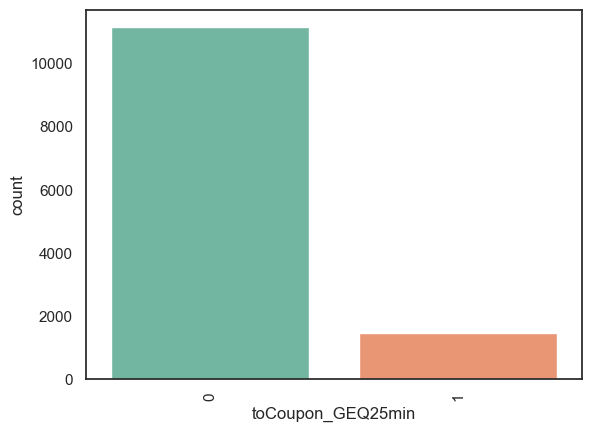

toCoupon_GEQ25min
0    88.398097
1    11.601903
Name: count, dtype: float64


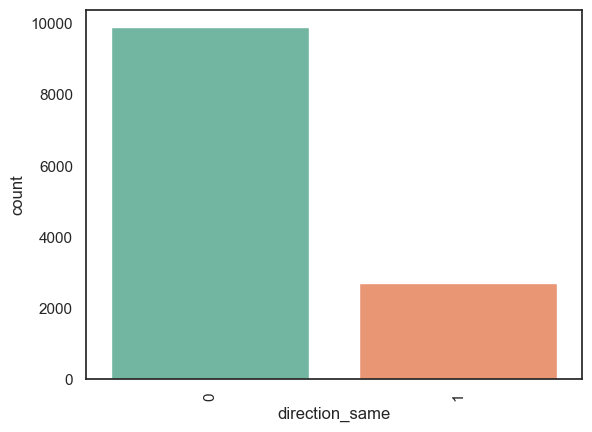

direction_same
0    78.445678
1    21.554322
Name: count, dtype: float64


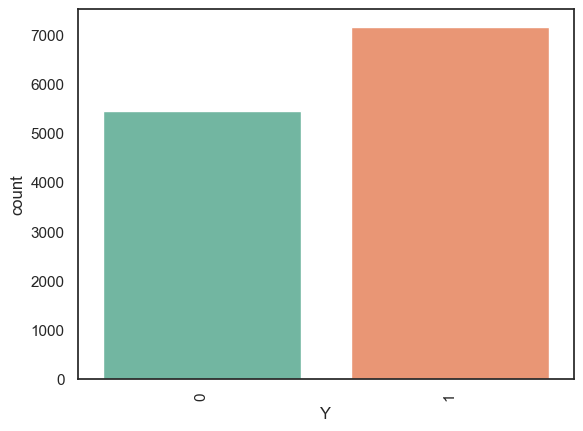

Y
1    56.756542
0    43.243458
Name: count, dtype: float64


In [307]:
#### Univariate analysis
for col in list:
    with sns.axes_style("white"):                     # sets the background to white
        sns.countplot(x = df[col] ,data = df, palette="Set2")     # countplot using seaborn library for every feature
        plt.xticks(rotation=90)                                   # rotates the x-axis labels at 90 degree andgle so they don't overlap
        plt.show()
        print(df[f"{col}"].value_counts()/len(df) * 100)          # printing value counts as percentages

In [308]:
# Creating a list of columns
cols = ['Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']
for col in cols:                              # looping through the list
    df[col].replace({          
                    "1~3":"1to3",
                      "4~8":"4to8",
                      "gt8":"More than 8"}, inplace=True)
    print(f"\n--- Value_counts for {col} ---\n")
    print(df[col].value_counts())


--- Value_counts for Bar ---

Bar
never          5285
less1          3438
1to3           2468
4to8           1071
More than 8     348
Name: count, dtype: int64

--- Value_counts for CoffeeHouse ---

CoffeeHouse
less1          3579
1to3           3199
never          2946
4to8           1779
More than 8    1107
Name: count, dtype: int64

--- Value_counts for CarryAway ---

CarryAway
1to3           4795
4to8           4242
less1          1849
More than 8    1572
never           152
Name: count, dtype: int64

--- Value_counts for RestaurantLessThan20 ---

RestaurantLessThan20
1to3           5485
4to8           3553
less1          2071
More than 8    1282
never           219
Name: count, dtype: int64

--- Value_counts for Restaurant20To50 ---

Restaurant20To50
less1          6230
1to3           3266
never          2122
4to8            728
More than 8     264
Name: count, dtype: int64


#### Bivariate Analysis

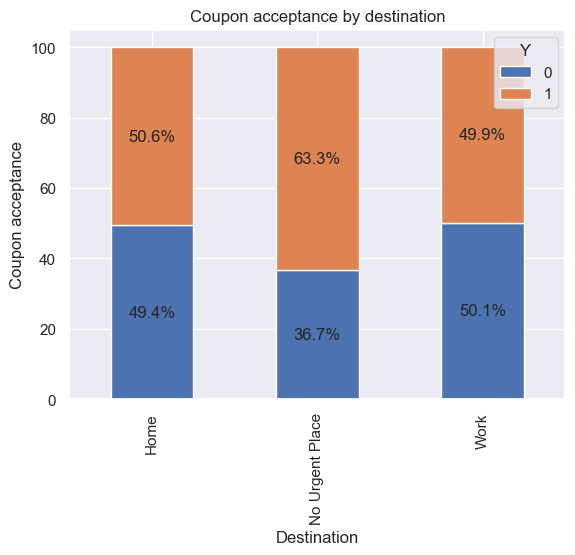

In [310]:
# acceptance by destination
# ensures plots are displayed in the notebook
%matplotlib inline      
crosstab = pd.crosstab(df.destination,df.Y,normalize='index') * 100    # creates a frequency table with rows as unique destination categories and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                            # Plotting a bar chart for created crosstab
for cont in ax.containers:                                             # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance by destination')                          # gives a title to the chart
plt.xlabel('Destination')                                              # labels the x-axis
plt.ylabel('Coupon acceptance')                                        # labels the y-axis
plt.show()

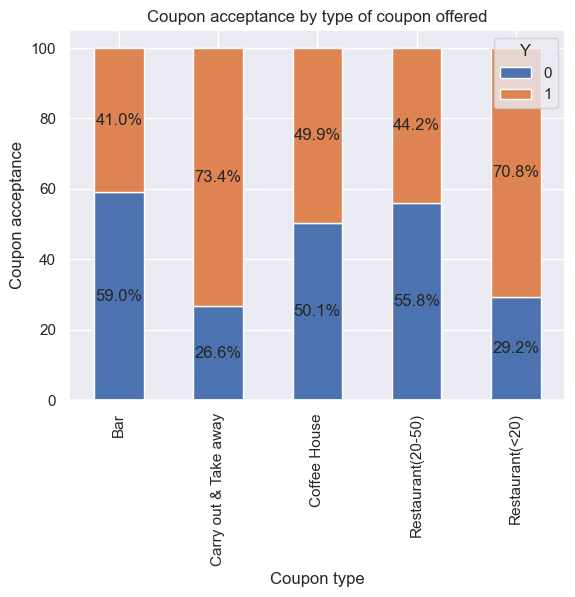

In [311]:
# acceptance by coupon type     
crosstab = pd.crosstab(df.coupon,df.Y,normalize='index') * 100         # creates a frequency table with rows as unique coupon types and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                            # Plotting a bar chart for created crosstab
for cont in ax.containers:                                             # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance by type of coupon offered')               # gives a title to the chart
plt.xlabel('Coupon type')                                              # labels the x-axis
plt.ylabel('Coupon acceptance')                                        # labels the y-axis
plt.show()

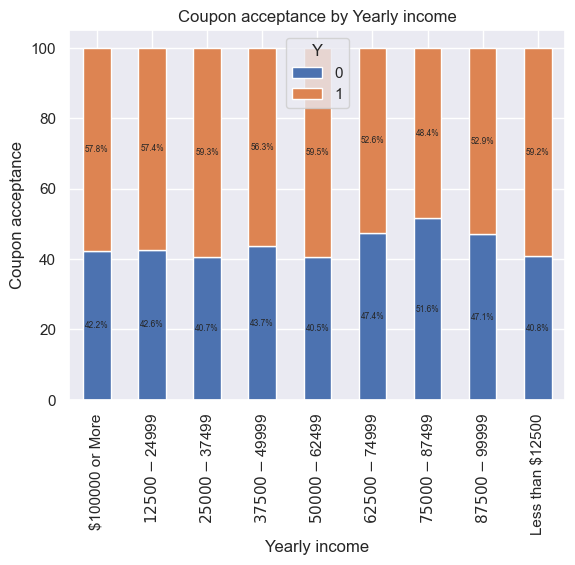

In [312]:
# acceptance by yearly income     
crosstab = pd.crosstab(df.income,df.Y,normalize='index') * 100         # creates a frequency table with rows as yearly income brackets and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                            # Plotting a bar chart for created crosstab
for cont in ax.containers:                                             # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0,
                fontsize=6)
plt.title('Coupon acceptance by Yearly income')                        # gives a title to the chart
plt.xlabel('Yearly income')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                        # labels the y-axis
plt.show()

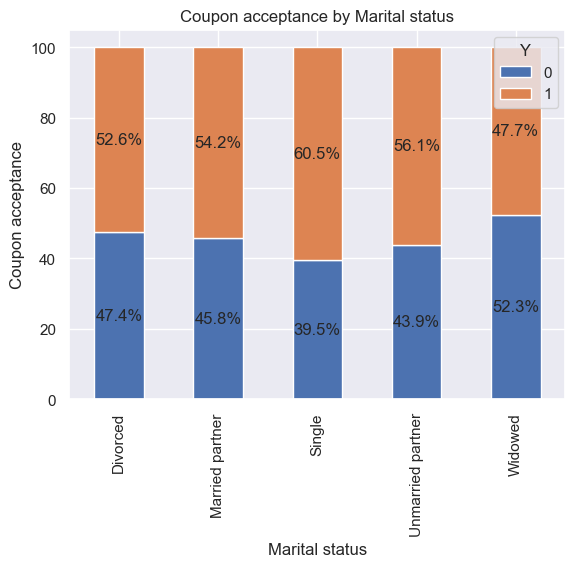

In [313]:
# acceptance by marital status     
crosstab = pd.crosstab(df.maritalStatus,df.Y,normalize='index') * 100  # creates a frequency table with rows as marital status and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                            # Plotting a bar chart for created crosstab
for cont in ax.containers:                                             # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance by Marital status')                       # gives a title to the chart
plt.xlabel('Marital status')                                           # labels the x-axis
plt.ylabel('Coupon acceptance')                                        # labels the y-axis
plt.show()

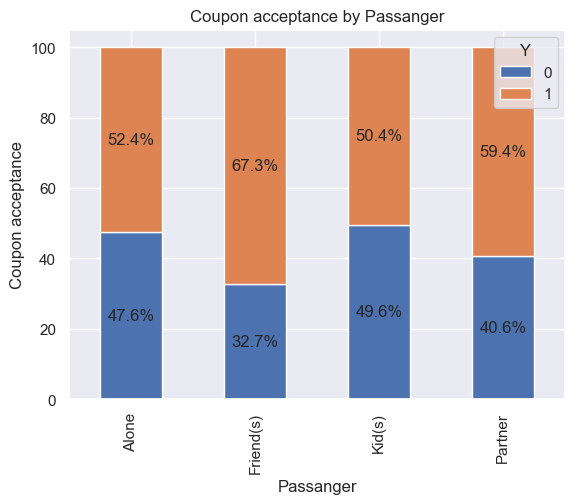

In [314]:
# acceptance by passanger  
crosstab = pd.crosstab(df.passanger,df.Y,normalize='index') * 100  # creates a frequency table with rows as passenger's and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                        # Plotting a bar chart for created crosstab
for cont in ax.containers:                                         # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance by Passanger')                        # gives a title to the chart
plt.xlabel('Passanger')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                    # labels the y-axis
plt.show()

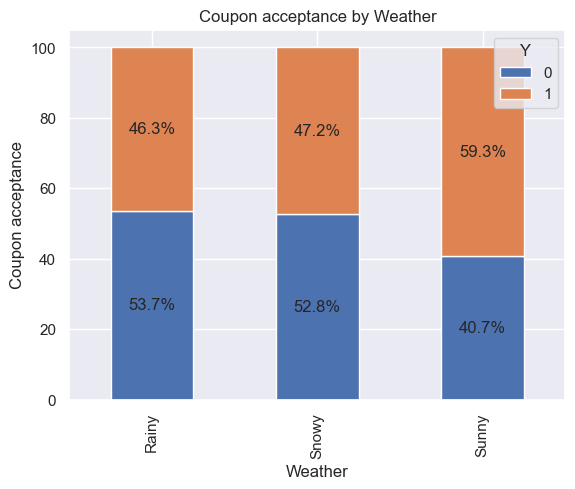

In [315]:
# acceptance by weather   
crosstab = pd.crosstab(df.weather,df.Y,normalize='index') * 100  # creates a frequency table with rows as marital status and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                      # Plotting a bar chart for created crosstab
for cont in ax.containers:                                       # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance by Weather')                        # gives a title to the chart
plt.xlabel('Weather')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                  # labels the y-axis
plt.show()

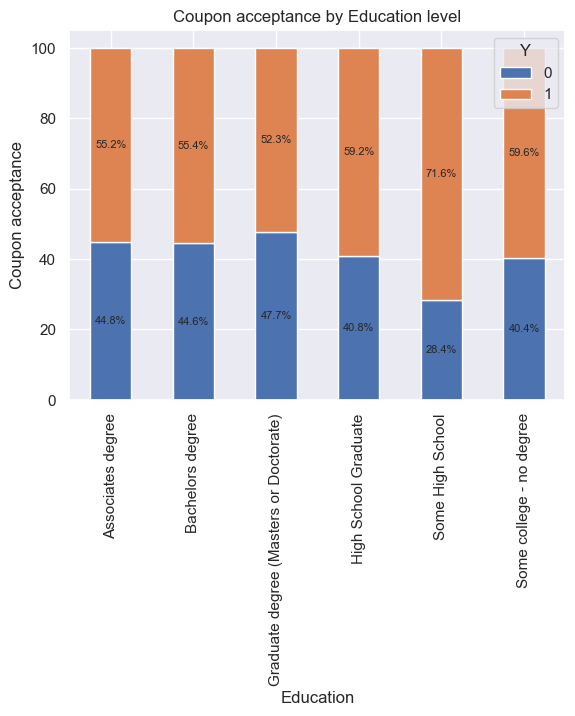

In [316]:
# acceptance by education   
crosstab = pd.crosstab(df.education,df.Y,normalize='index') * 100  # creates a frequency table with rows as educational level and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                      # Plotting a bar chart for created crosstab
for cont in ax.containers:                                       # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0,
                fontsize=8)
plt.title('Coupon acceptance by Education level')                        # gives a title to the chart
plt.xlabel('Education')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                  # labels the y-axis
plt.show()

In [317]:
# User's who haven't completed high school have the highest coupon acceptance percentage followed by high school graduates and no-degree.

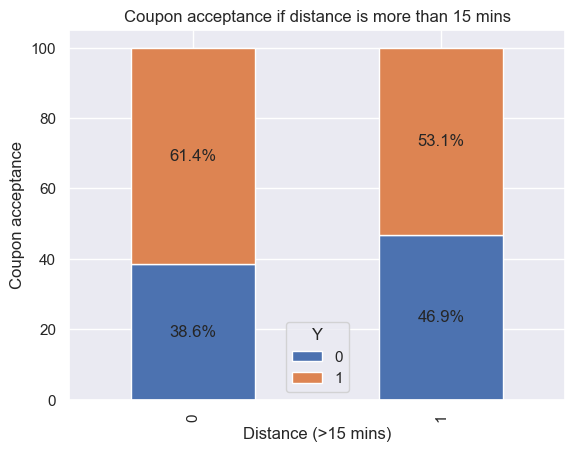

In [318]:
# acceptance if distance is more than 15mins   
crosstab = pd.crosstab(df.toCoupon_GEQ15min,df.Y,normalize='index') * 100  # creates a frequency table with rows values of feature and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                      # Plotting a bar chart for created crosstab
for cont in ax.containers:                                       # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance if distance is more than 15 mins')                        # gives a title to the chart
plt.xlabel('Distance (>15 mins)')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                  # labels the y-axis
plt.show()

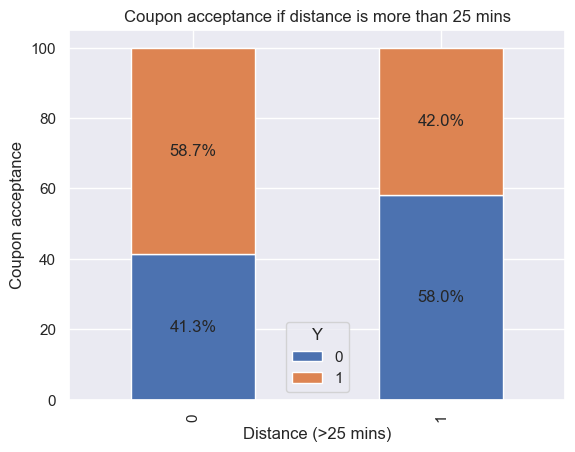

In [319]:
# acceptance if distance is more than 25mins   
crosstab = pd.crosstab(df.toCoupon_GEQ25min,df.Y,normalize='index') * 100  # creates a frequency table with rows values of feature and coupon acceptance as columns
ax = crosstab.plot(kind='bar',stacked=True)                      # Plotting a bar chart for created crosstab
for cont in ax.containers:                                       # Adding annotations to the graph
    ax.bar_label(cont,
                label_type='center',
                fmt = '%.1f%%',
                padding=0)
plt.title('Coupon acceptance if distance is more than 25 mins')                        # gives a title to the chart
plt.xlabel('Distance (>25 mins)')                                            # labels the x-axis
plt.ylabel('Coupon acceptance')                                  # labels the y-axis
plt.show()

In [320]:
# dataframe summarization
cols = df.columns.to_list()
c = [col for col in cols if col != 'Y']

# As all the variables are categorical, we can display the mode or frequency count
categorical_values_by_group = df.groupby('Y')[c].agg(lambda x: x.mode().iloc[0])

print("\nMode values by group for categorical columns:")
print(categorical_values_by_group)


Mode values by group for categorical columns:
       destination passanger weather  temperature time        coupon  \
Y                                                                      
0  No Urgent Place     Alone   Sunny           80  7AM  Coffee House   
1  No Urgent Place     Alone   Sunny           80  6PM  Coffee House   

  expiration  gender age    maritalStatus  has_children  \
Y                                                         
0         2h  Female  21  Married partner             0   
1         1d    Male  21           Single             0   

                  education  occupation           income    Bar CoffeeHouse  \
Y                                                                             
0          Bachelors degree  Unemployed  $25000 - $37499  never       less1   
1  Some college - no degree  Unemployed  $25000 - $37499  never        1to3   

  CarryAway RestaurantLessThan20 Restaurant20To50  toCoupon_GEQ15min  \
Y                                     

## Feature Engineering

In [322]:
# creating the conditions
cond = [(df['toCoupon_GEQ15min'] == 0) & (df['toCoupon_GEQ25min'] == 0),
       (df['toCoupon_GEQ15min'] == 1) & (df['toCoupon_GEQ25min'] == 0),
       (df['toCoupon_GEQ15min'] == 1) & (df['toCoupon_GEQ25min'] == 1)]
vals = [0,1,2]
df['dist_to_coupon'] = np.select(cond,vals,default=np.nan)
print(df['dist_to_coupon'].value_counts())

dist_to_coupon
1.0    5596
0.0    5551
2.0    1463
Name: count, dtype: int64


In [323]:
# drop the original features from the dataframe
df.drop(columns = ['toCoupon_GEQ15min','toCoupon_GEQ25min'],inplace=True)

In [324]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,education,occupation,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,direction_same,Y,dist_to_coupon
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1to3,4to8,1to3,0,1,0.0
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1to3,4to8,1to3,0,0,0.0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1to3,4to8,1to3,0,1,1.0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1to3,4to8,1to3,0,0,1.0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,1,Some college - no degree,Unemployed,$37500 - $49999,never,never,1to3,4to8,1to3,0,0,1.0


In [325]:
# Creating dummies for the categorical variables which are not in the form of '0' and '1' using pandas function get_dummies
cols = ['destination','passanger','weather','temperature','time','coupon','expiration','gender','age','maritalStatus','education','occupation','income','Bar','CoffeeHouse','CarryAway','RestaurantLessThan20','Restaurant20To50']

df_encoded = pd.get_dummies(df,columns = cols)

In [326]:
df_encoded.head()

,has_children,direction_same,Y,dist_to_coupon,destination_Home,destination_No Urgent Place,destination_Work,passanger_Alone,passanger_Friend(s),passanger_Kid(s),passanger_Partner,weather_Rainy,weather_Snowy,weather_Sunny,temperature_30,temperature_55,temperature_80,time_10AM,time_10PM,time_2PM,time_6PM,time_7AM,coupon_Bar,coupon_Carry out & Take away,coupon_Coffee House,coupon_Restaurant(20-50),coupon_Restaurant(<20),expiration_1d,expiration_2h,gender_Female,gender_Male,age_21,age_26,age_31,age_36,age_41,age_46,age_50plus,age_below21,maritalStatus_Divorced,maritalStatus_Married partner,maritalStatus_Single,maritalStatus_Unmarried partner,maritalStatus_Widowed,education_Associates degree,education_Bachelors degree,education_Graduate degree (Masters or Doctorate),education_High School Graduate,education_Some High School,education_Some college - no degree,occupation_Architecture & Engineering,occupation_Arts Design Entertainment Sports & Media,occupation_Business & Financial,occupation_Community & Social Services,occupation_Computer & Mathematical,occupation_Construction & Extraction,occupation_Education&Training&Library,occupation_Food Preparation & Serving Related,occupation_Healthcare Practitioners & Technical,occupation_Healthcare Support,occupation_Installation Maintenance & Repair,occupation_Legal,occupation_Life Physical Social Science,occupation_Management,occupation_Office & Administrative Support,occupation_Other,occupation_Personal Care & Service,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed,income_$100000 or More,income_$12500 - $24999,income_$25000 - $37499,income_$37500 - $49999,income_$50000 - $62499,income_$62500 - $74999,income_$75000 - $87499,income_$87500 - $99999,income_Less than $12500,Bar_1to3,Bar_4to8,Bar_More than 8,Bar_less1,Bar_never,CoffeeHouse_1to3,CoffeeHouse_4to8,CoffeeHouse_More than 8,CoffeeHouse_less1,CoffeeHouse_never,CarryAway_1to3,CarryAway_4to8,CarryAway_More than 8,CarryAway_less1,CarryAway_never,RestaurantLessThan20_1to3,RestaurantLessThan20_4to8,RestaurantLessThan20_More than 8,RestaurantLessThan20_less1,RestaurantLessThan20_never,Restaurant20To50_1to3,Restaurant20To50_4to8,Restaurant20To50_More than 8,Restaurant20To50_less1,Restaurant20To50_never
0,1,0,1,0.0,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
1,1,0,0,0.0,False,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,True,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False
2,1,0,1,1.0,False,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False,True,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,F

In [327]:
X = df_encoded.drop('Y',axis=1)

In [328]:
y = df_encoded['Y']

## Model Implementation

#### Logistic Regression Model

In [331]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=0)

In [332]:
model_1 = LogisticRegression()
model_1.fit(X_train, y_train)    # Fitting the model on training data

LogisticRegression()

In [333]:
y_pred = model_1.predict(X_test)   # Examining the prediction accuracy on test data

# Calculating the accuracy
print('Accuracy of logistic regression on test set: {:2f}'.format(model_1.score(X_test,y_test)))

Accuracy of logistic regression on test set: 0.678033


#### Cross-validation

In [335]:
# Using 10-fold CV to avoid overfitting of the model
from sklearn import model_selection
from sklearn.model_selection import cross_val_score

kfold = model_selection.KFold(n_splits = 10, random_state = 7, shuffle= True)    # defining number of splits and shuffle=True randomizes the data

modelCV = LogisticRegression()

score = 'accuracy'      # using accuracy to evaluate performance

results = model_selection.cross_val_score(modelCV, X_train,y_train, cv = kfold, scoring = score)

print("10-fold cross-validation average accuracy : %.3f" % (results.mean()))           # printing the mean accuracy from the 10-fold cv i.e. 10 runs of the models

10-fold cross-validation average accuracy : 0.687


#### Confusion matrix and classification report

In [337]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test,y_pred)
print(conf_mat)

[[ 610  463]
 [ 349 1100]]


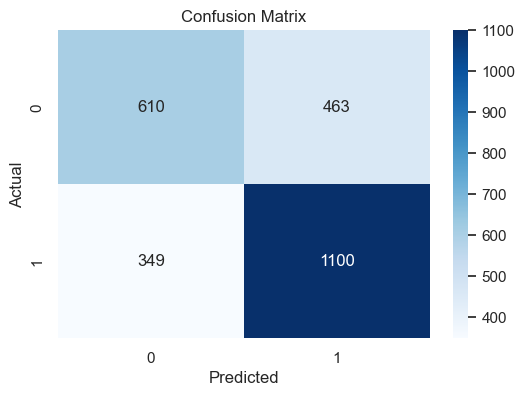

In [338]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")      # plotting a heatmap of the confusionmatrix for ease of understanding
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [339]:
from sklearn.metrics import classification_report
class_rep = classification_report(y_test,y_pred)         # evaluation metrics to analyze the models performance
print(class_rep)

              precision    recall  f1-score   support

           0       0.64      0.57      0.60      1073
           1       0.70      0.76      0.73      1449

    accuracy                           0.68      2522
   macro avg       0.67      0.66      0.67      2522
weighted avg       0.67      0.68      0.68      2522



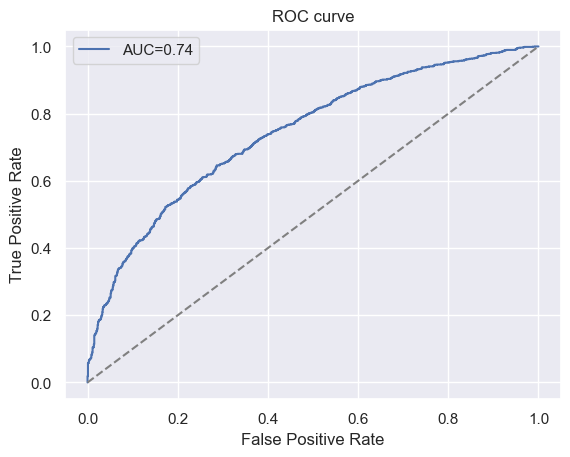

In [340]:
from sklearn.metrics import roc_curve, roc_auc_score
y_true = y_test                                    # Actual '0' and '1' values in the test dataset
y_scores = model_1.predict_proba(X_test)[:, 1]     # Prediction probability scores of class 1
fpr,tpr,thresholds = roc_curve(y_true,y_scores)
auc_score = roc_auc_score(y_true,y_scores)

# Plotting the ROC-AUC curve to undertand true positives against false positives and models ability to distinguish between them
plt.plot(fpr,tpr,label=f"AUC={auc_score:.2f}")
plt.plot([0,1],[0,1],linestyle = '--',color='gray') # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()

#### We will now fit a random forest model and see if it provides a better accuracy or not.

## Random Forest Classifier

In [343]:
model_2 = RandomForestClassifier(random_state=0)
model_2.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [344]:
y_pred_1 = model_2.predict(X_test)

# Calculating the accuracy
print('Accuracy of random forest classifier on test set: {:2f}'.format(model_2.score(X_test,y_test)))

Accuracy of random forest classifier on test set: 0.750198


#### Cross-Validation

In [346]:
# Using 10-fold CV to avoid overfitting of the model
kfold_1 = model_selection.KFold(n_splits = 10, random_state = 7, shuffle= True)

modelCV_1 = RandomForestClassifier()

scoring_1 = 'accuracy'

results_1 = model_selection.cross_val_score(modelCV_1, X_train,y_train, cv = kfold_1, scoring = scoring_1)

print("10-fold cross-validation average accuracy : %.3f" % (results_1.mean()))

10-fold cross-validation average accuracy : 0.752


In [347]:
model_2.get_params()    # getting the default parameters used by the model

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

#### Confusion Matrix and classification report

In [349]:
conf_mat_1 = confusion_matrix(y_test,y_pred_1)
print(conf_mat_1)

[[ 709  364]
 [ 266 1183]]


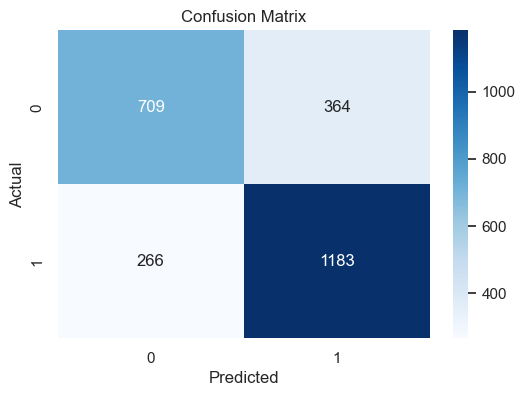

In [350]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat_1, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [351]:
class_rep = classification_report(y_test,y_pred_1)
print(class_rep)

              precision    recall  f1-score   support

           0       0.73      0.66      0.69      1073
           1       0.76      0.82      0.79      1449

    accuracy                           0.75      2522
   macro avg       0.75      0.74      0.74      2522
weighted avg       0.75      0.75      0.75      2522



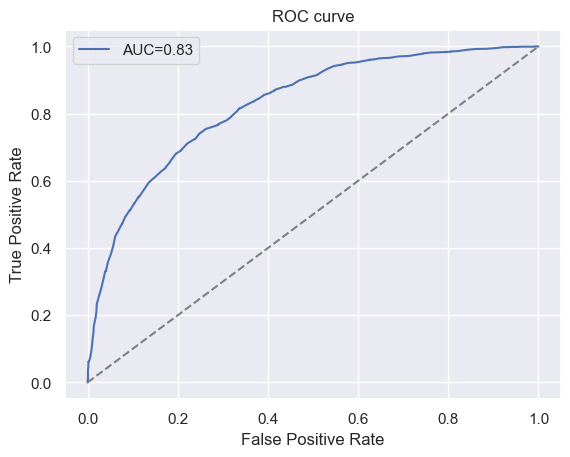

In [352]:
y_true = y_test                                      # Actual '0' and '1' values in the test dataset
y_scores_1 = model_2.predict_proba(X_test)[:, 1]     # Prediction probability scores of class 1
fpr,tpr,thresholds = roc_curve(y_true,y_scores_1)
auc_score = roc_auc_score(y_true,y_scores_1)

# Plotting the ROC-AUC curve to undertand true positives against false positives and models ability to distinguish between them
plt.plot(fpr,tpr,label=f"AUC={auc_score:.2f}")
plt.plot([0,1],[0,1],linestyle = '--',color='gray') # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()

#### Hence, we can say that Random Forest Classifier is good model for this problem and does a good job at predicting the outcomes. For the problem at hand, we have achieved 75% accuracy with this model which is pretty good considering the number of features and various categories present in some of the features.

#### Hyper-Parameter Tuning

In [355]:
rf_params = {                                          # a dictionary of parameters to try and improve the model performance further
    'n_estimators':[50,100,200,500],
    'max_depth': [5,10,20,None],
    'min_samples_split':[2,5,10]
}

In [356]:
model_3 = RandomForestClassifier(random_state=0)
grid_rf = GridSearchCV(model_3,rf_params,cv=10,n_jobs=-1)

In [357]:
grid_rf.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200, 500]})

In [358]:
print(f'Best Random Forest Alpha: ',grid_rf.best_params_)       # getting the best parameters out of the values passed using the dictionary
print(f'Best Random Forest: ',grid_rf.best_score_)              # printing the best accuracy

Best Random Forest Alpha:  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 500}
Best Random Forest:  0.7595131908065506


In [359]:
best_rf = grid_rf.best_estimator_
y_pred_rf_ = best_rf.predict(X_test)          # training the model with best parameters on the test data set

# Calculating the accuracy
print('Accuracy of random forest classifier on test set: {:2f}'.format(best_rf.score(X_test,y_test)))  # printing the accuracy

Accuracy of random forest classifier on test set: 0.758525


In [360]:
conf_mat_rf = confusion_matrix(y_test,y_pred_rf_)
print(conf_mat_rf)

[[ 705  368]
 [ 241 1208]]


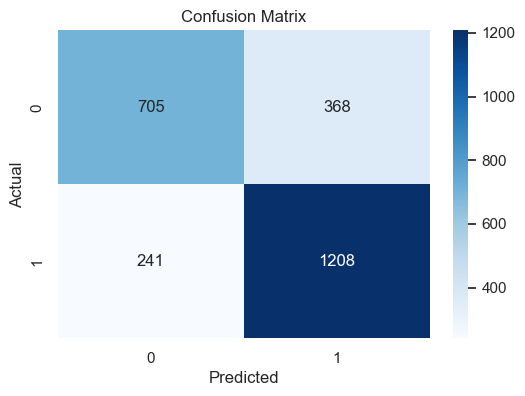

In [361]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_mat_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [362]:
class_rep = classification_report(y_test,y_pred_rf_)
print(class_rep)

              precision    recall  f1-score   support

           0       0.75      0.66      0.70      1073
           1       0.77      0.83      0.80      1449

    accuracy                           0.76      2522
   macro avg       0.76      0.75      0.75      2522
weighted avg       0.76      0.76      0.76      2522



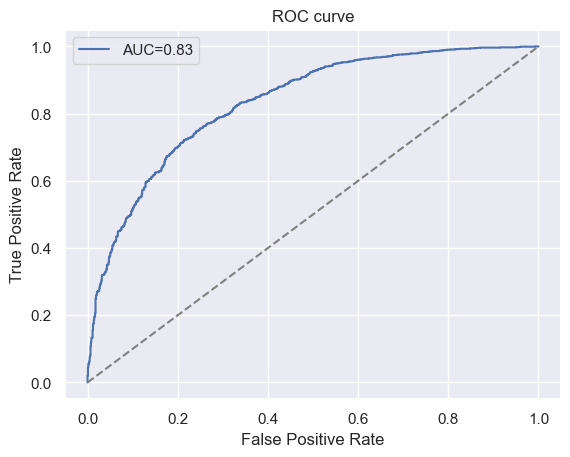

In [363]:
y_true = y_test                                      # Actual '0' and '1' values in the test dataset
y_scores_rf = best_rf.predict_proba(X_test)[:, 1]     # Prediction probability scores of class 1
fpr,tpr,thresholds = roc_curve(y_true,y_scores_rf)
auc_score_rf = roc_auc_score(y_true,y_scores_rf)

# Plotting the ROC-AUC curve to undertand true positives against false positives and models ability to distinguish between them
plt.plot(fpr,tpr,label=f"AUC={auc_score_rf:.2f}")
plt.plot([0,1],[0,1],linestyle = '--',color='gray') # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend()
plt.show()

#### With this we can conclude that Random Forest Classifier is a good model for this dataset and achieves an overall accuracy of 76% which is good considering the cardinality of a few categorical variables and the partial class imbalance present in the dependent variable.